## **Imports**


In [1]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, precision_recall_curve
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
import csv
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
from scipy.sparse import hstack, csr_matrix

## **Read the data file**

In [2]:

file_path = "linkedin pii_detection_results_with_regex_and_gazetteer.csv"

data = []
with open(file_path, 'r', encoding='utf-8-sig', newline='') as f:
    reader = csv.reader(f)
    for row in reader:
        data.append(row)

# Assuming the first row is the header
if data:
    header = data[0]
    df_data = data[1:]
    fb_pii_df = pd.DataFrame(df_data, columns=header)
    print("DataFrame created successfully.")
    print(fb_pii_df.head())
else:
    print("The CSV file is empty or could not be read.")

DataFrame created successfully.
  Original_DataFrame_Index                                      Original_Text  \
0                        0  ***Update**** - Only one spot remains  Due to ...   
1                        1  More info than Wikipedia... and with fewer don...   
2                        2  This blood donation app connects donors and re...   
3                        3  (Sofar 35k sent to her) We received this donat...   
4                        3  (Sofar 35k sent to her) We received this donat...   

  PII_Entity  PII_Type               Score Source     Exposure_Score  
0                                            None  7.833333333333333  
1                                            None  5.166666666666667  
2                                            None                4.5  
3         35  B-AMOUNT  0.5413079857826233  Model              427.5  
4        ##k  I-AMOUNT  0.7191131711006165  Model              427.5  


In [3]:
fb_pii_df.head(3)

,Original_DataFrame_Index,Original_Text,PII_Entity,PII_Type,Score,Source,Exposure_Score
0,0,***Update**** - Only one spot remains Due to ...,,,,None,7.833333333333333
1,1,More info than Wikipedia... and with fewer don...,,,,None,5.166666666666667
2,2,This blood donation app connects donors and re...,,,,None,4.5


In [4]:
# המרת האינדקס למספר כדי שהמיון בקיבוץ יהיה תקין
fb_pii_df['Original_DataFrame_Index'] = fb_pii_df['Original_DataFrame_Index'].astype(int)
class_df = fb_pii_df.copy()
# קיבוץ לפי אינדקס הפוסט המקורי
class_df = fb_pii_df.groupby('Original_DataFrame_Index').agg({
    'Original_Text': 'first',
    'Exposure_Score': 'first',
    # בדיקה שהערך אינו NaN וגם אינו ריק/מכיל רק רווחים
    'PII_Entity': lambda x: x.dropna().astype(str).str.strip().ne('').any()
}).reset_index()

# שינוי שם והמרה ל-0/1
class_df.rename(columns={'PII_Entity': 'Label_Has_PII'}, inplace=True)
class_df['Label_Has_PII'] = class_df['Label_Has_PII'].astype(int)

print(f"num of posts in class_df: {len(class_df)}")
class_df.head()

num of posts in class_df: 18290


,Original_DataFrame_Index,Original_Text,Exposure_Score,Label_Has_PII
0,0,***Update**** - Only one spot remains Due to ...,7.833333333333333,0
1,1,More info than Wikipedia... and with fewer don...,5.166666666666667,0
2,2,This blood donation app connects donors and re...,4.5,0
3,3,(Sofar 35k sent to her) We received this donat...,427.5,1
4,4,(Sofar 5k recd & sent to her) We received this...,196.5,1


In [5]:
# Calculate the number of posts where Label_Has_PII is 0
num_of_posts_with_no_PII = len(class_df[class_df['Label_Has_PII'] == 0])
print(num_of_posts_with_no_PII)

1235


## **Feature Engineering: Row level**

In [6]:
# Fill missing text with empty string to avoid errors
class_df['Original_Text'] = class_df['Original_Text'].fillna('')

# 1. Word count per row
class_df['Word_Count'] = class_df['Original_Text'].apply(lambda x: len(x.split()))

# 2. Character count with spaces
class_df['Char_Count_With_Spaces'] = class_df['Original_Text'].apply(len)

# 3. Character count without spaces
class_df['Char_Count_No_Spaces'] = class_df['Original_Text'].apply(lambda x: len(x.replace(" ", "")))

# 4. Count of individual digits (0-9)
class_df['Digit_Count'] = class_df['Original_Text'].apply(lambda x: sum(c.isdigit() for c in x))

# 5. Count of whole numbers (sequences of digits)
class_df['Number_Count'] = class_df['Original_Text'].apply(lambda x: len(re.findall(r'\b\d+\b', x)))

# 6. Apply log transformation using log1p (which computes log(x+1)) to safely handle zeros
class_df['Number_Count_Log'] = np.log1p(class_df['Number_Count'])

# 7.
class_df['Digit_Count_Log'] = np.log1p(class_df['Digit_Count'])

# 8.
class_df['Char_Count_Log'] = np.log1p(class_df['Char_Count_No_Spaces'])

# 9.
class_df['Word_Count_Log'] = np.log1p(class_df['Word_Count'])

## **Create train & test set**

In [7]:
# Separate features (X) and target variable (y)
X = class_df.drop(columns=['Label_Has_PII'])
y = class_df['Label_Has_PII']

### Method 1

In [8]:
# # Perform stratified train-test split to maintain the ratio of classes (0 and 1)
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y,
#     test_size=0.2,
#     stratify=y,
#     random_state=42
# )

### Method 2

In [9]:
# Define 5 different splits, with 20% for testing in each
sss = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# A list to store the generated train and test sets for each split
splits = []

# Iterate over each split to generate the datasets
for train_index, test_index in sss.split(X, y):
    # Extract data based on the indices of the current split
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Save the current split for future model training
    splits.append((X_train, X_test, y_train, y_test))

In [10]:
# 1. Calculate proportions in the original dataset
overall_proportions = class_df['Label_Has_PII'].value_counts() / len(class_df)

# 2. Create a random split (Random Sampling) for comparison
_, test_set_random = train_test_split(class_df, test_size=0.2, random_state=42)
random_proportions = test_set_random['Label_Has_PII'].value_counts() / len(test_set_random)

# 3. Extract proportions from the first Stratified Sampling split you created
_, _, _, y_test_strat = splits[0]
strat_proportions = y_test_strat.value_counts() / len(y_test_strat)

# Build the DataFrame
compare_props = pd.DataFrame({
    "Overall %": overall_proportions,
    "Stratified %": strat_proportions,
    "Random %": random_proportions,
}).sort_index()

# Multiply by 100 to display as percentages
compare_props = compare_props * 100

# Calculate the Error % relative to the original set, similar to the book
compare_props["Strat. Error %"] = 100 * compare_props["Stratified %"] / compare_props["Overall %"] - 100
compare_props["Rand. Error %"] = 100 * compare_props["Random %"] / compare_props["Overall %"] - 100

# Round the results to 2 decimal places for a clean display
compare_props.index.name = "Label_Has_PII"
compare_props = compare_props.round(2)

compare_props

,Overall %,Stratified %,Random %,Strat. Error %,Rand. Error %
Label_Has_PII,,,,,
0,6.75,6.75,7.27,0.0,7.69
1,93.25,93.25,92.73,0.0,-0.56


## **Feature Engineering: Corpus-level**

In [11]:
# Define the numerical columns that need normalization
num_cols = [
    'Word_Count',
    'Char_Count_With_Spaces',
    'Char_Count_No_Spaces',
    'Digit_Count',
    'Number_Count',
    'Number_Count_Log',
    'Digit_Count_Log'
]

# 1. Normalize numerical features (Corpus level scaling)
scaler = StandardScaler()

# Fit on Train, transform both Train and Test
X_train_scaled = scaler.fit_transform(X_train[num_cols])
X_test_scaled = scaler.transform(X_test[num_cols])

# 2. Unique Vectors (Bag of Words / CountVectorizer)
count_vec = CountVectorizer()

# Fit vocabulary on Train, transform both
X_train_counts = count_vec.fit_transform(X_train['Original_Text'])
X_test_counts = count_vec.transform(X_test['Original_Text'])

# 3. TF-IDF Representation
tfidf_vec = TfidfVectorizer()

# Fit IDF stats on Train, transform both
X_train_tfidf = tfidf_vec.fit_transform(X_train['Original_Text'])
X_test_tfidf = tfidf_vec.transform(X_test['Original_Text'])

# 4. Combine all features into a single sparse matrix for the model
# hstack horizontally concatenates the scaled numbers, counts, and TF-IDF vectors
X_train_final = hstack([X_train_scaled, X_train_counts, X_train_tfidf])
X_test_final = hstack([X_test_scaled, X_test_counts, X_test_tfidf])

## **EDA**

### Basic

In [12]:
# Convert Exposure_Score to numeric, coercing errors to NaN and filling with 0
class_df['Exposure_Score'] = pd.to_numeric(class_df['Exposure_Score'], errors='coerce').fillna(0)

# Update X_train and X_test as well to ensure they reflect the change
if 'X_train' in locals():
    X_train['Exposure_Score'] = pd.to_numeric(X_train['Exposure_Score'], errors='coerce').fillna(0)

if 'X_test' in locals():
    X_test['Exposure_Score'] = pd.to_numeric(X_test['Exposure_Score'], errors='coerce').fillna(0)

print("Exposure_Score converted to numeric.")
print(class_df['Exposure_Score'].describe())

Exposure_Score converted to numeric.
count     18290.000000
mean         76.893913
std        2401.631107
min           0.000000
25%           0.166667
50%           0.833333
75%           4.000000
max      252252.666667
Name: Exposure_Score, dtype: float64


In [13]:
X_train.sample(5)

,Original_DataFrame_Index,Original_Text,Exposure_Score,Word_Count,Char_Count_With_Spaces,Char_Count_No_Spaces,Digit_Count,Number_Count,Number_Count_Log,Digit_Count_Log,Char_Count_Log,Word_Count_Log
9003,14112,Job Title: Informatica MDM Developer with hea...,0.000000,33,262,226,14,4,1.609438,2.708050,5.424950,3.526361
2496,2785,If you are a PMO based in Dublin and looking f...,4.166667,25,149,124,0,0,0.000000,0.000000,4.828314,3.258097
15089,23897,Today on 03/11 we celebrate our Infantry Rifle...,582.833333,19,132,110,4,2,1.098612,1.609438,4.709530,2.995732
16532,25412,Looking to elevate your hotel or restaurant’s ...,1.000000,168,1332,1156,19,1,0.693147,2.995732,7.053586,5.129899
2140,2426,I’m here all day at women of silicon roundabou...,4.333333,72,460,382,3,0,0.000000,1.386294,5.948035,4.290459


In [14]:
print("--- Train Set Info ---")
X_train.info()
print("\n--- Train Set Descriptive Statistics ---")
print(X_train.describe())

--- Train Set Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 14632 entries, 5439 to 15694
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Original_DataFrame_Index  14632 non-null  int64  
 1   Original_Text             14632 non-null  object 
 2   Exposure_Score            14632 non-null  float64
 3   Word_Count                14632 non-null  int64  
 4   Char_Count_With_Spaces    14632 non-null  int64  
 5   Char_Count_No_Spaces      14632 non-null  int64  
 6   Digit_Count               14632 non-null  int64  
 7   Number_Count              14632 non-null  int64  
 8   Number_Count_Log          14632 non-null  float64
 9   Digit_Count_Log           14632 non-null  float64
 10  Char_Count_Log            14632 non-null  float64
 11  Word_Count_Log            14632 non-null  float64
dtypes: float64(5), int64(6), object(1)
memory usage: 1.5+ MB

--- Train Set Descriptive Statistics 

## Visualization

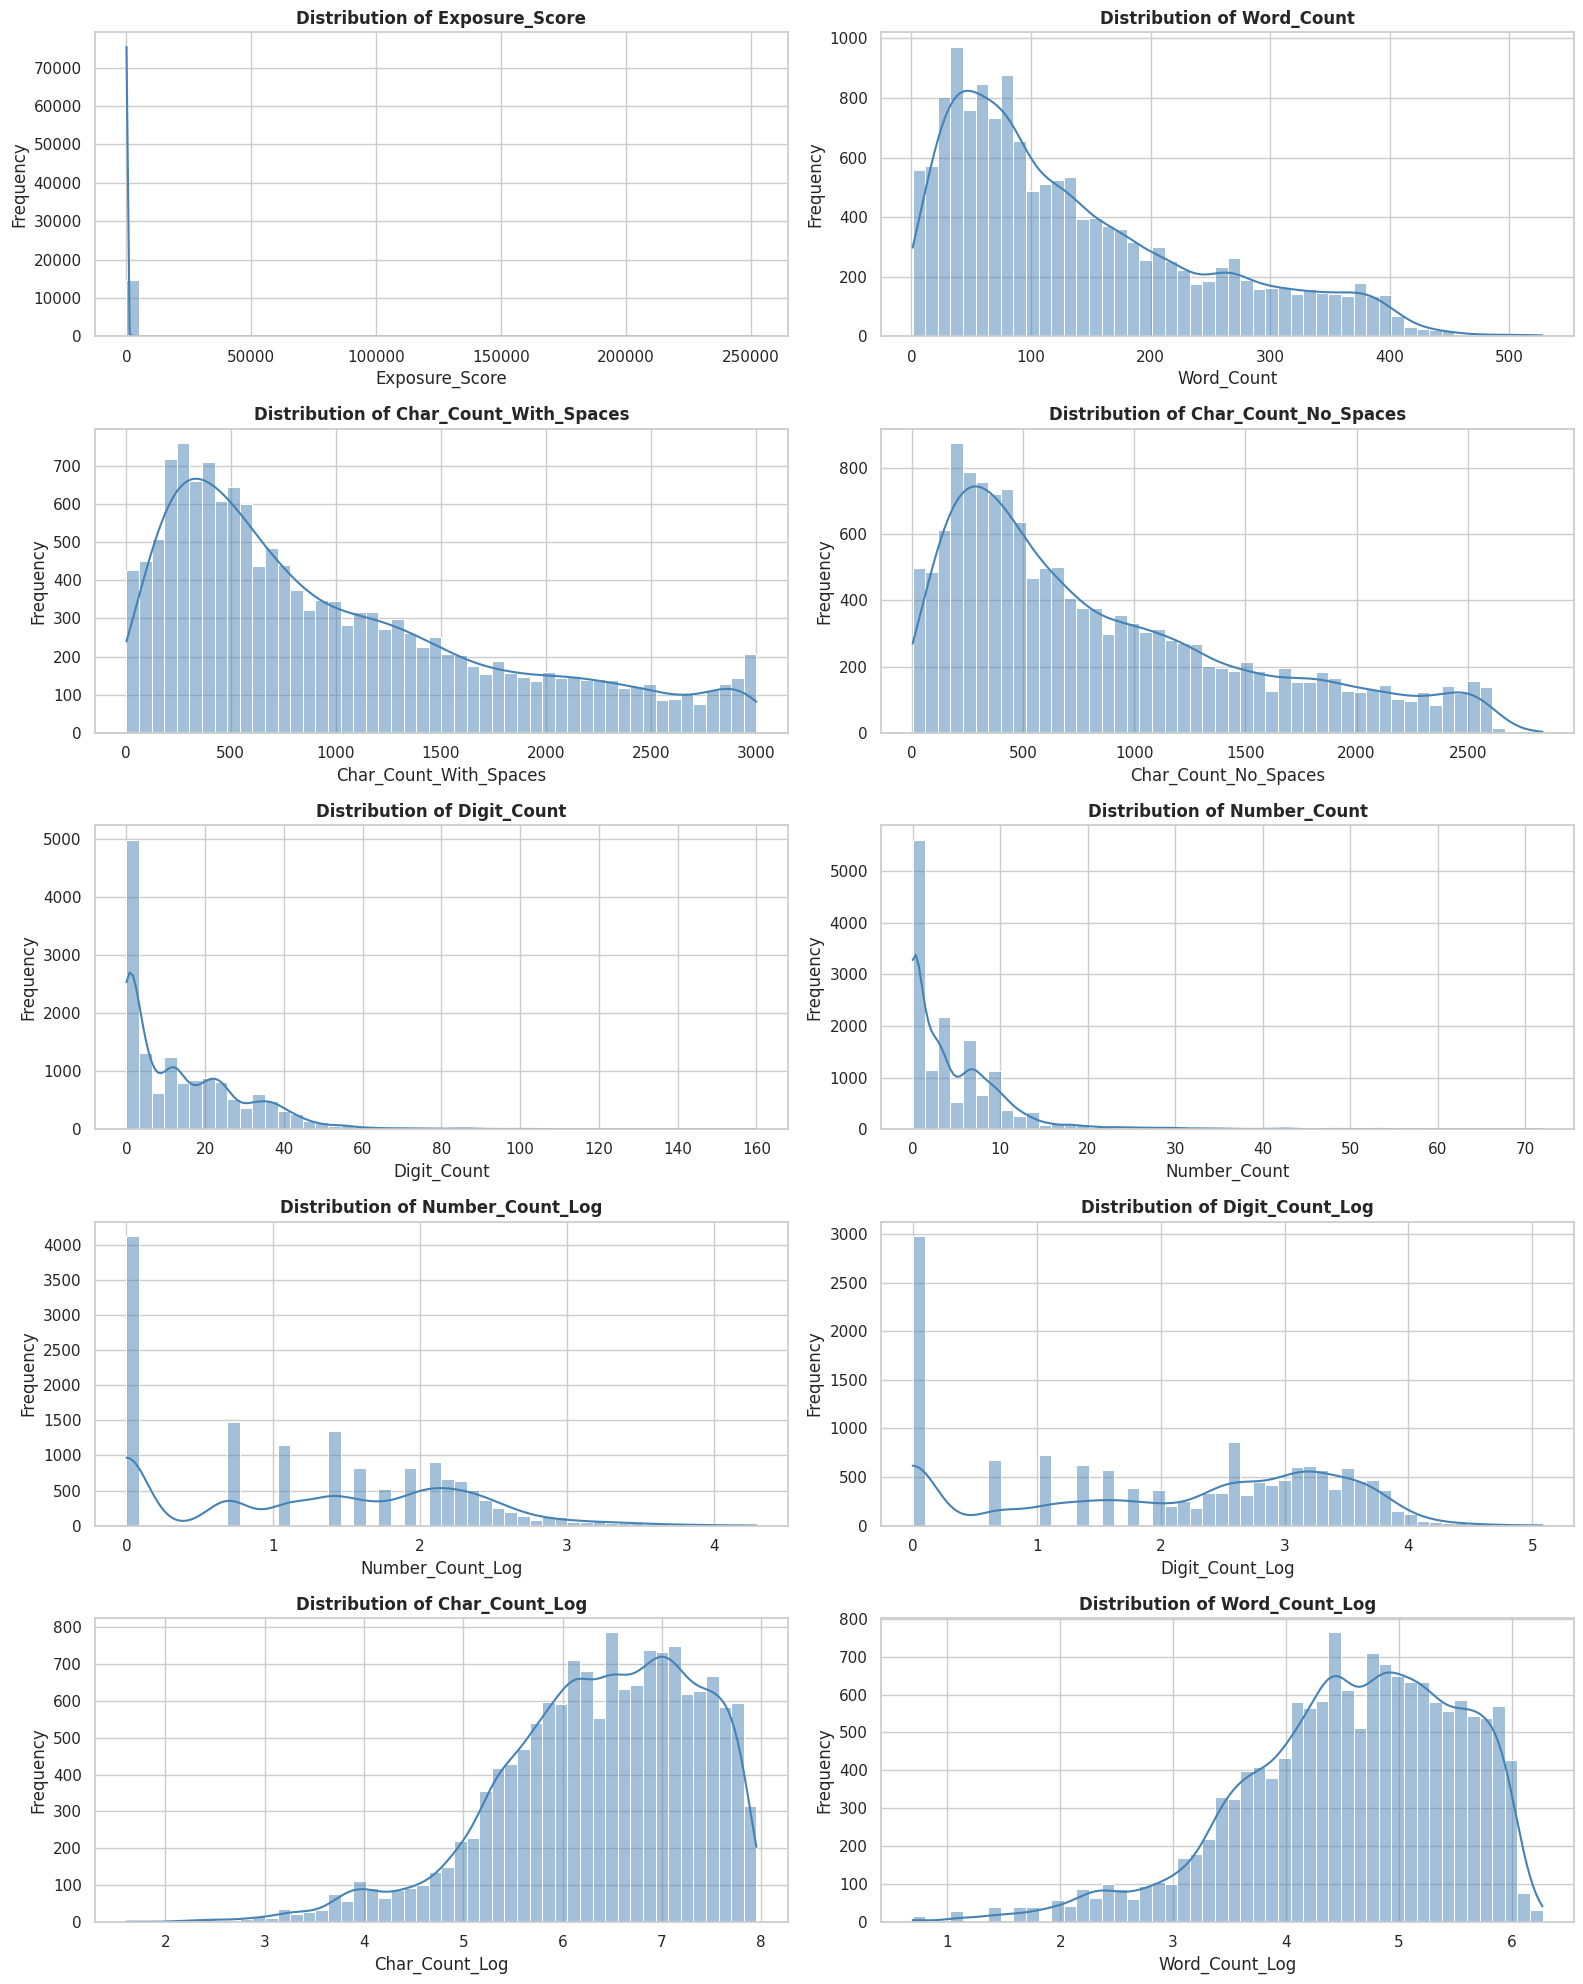

In [15]:
# Define all numerical columns to visualize
num_cols = [
    'Exposure_Score',
    'Word_Count',
    'Char_Count_With_Spaces',
    'Char_Count_No_Spaces',
    'Digit_Count',
    'Number_Count',
    'Number_Count_Log',
    'Digit_Count_Log',
    'Char_Count_Log',
    'Word_Count_Log'
]

# Set the visualization style
sns.set_theme(style="whitegrid")

# Create a figure with subplots (5 rows, 2 columns)
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 20))
axes = axes.flatten()

# Plot the distribution (histogram + KDE) for each numerical feature
for i, col in enumerate(num_cols):
    sns.histplot(X_train[col], bins=50, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Adjust layout to prevent overlapping text
plt.tight_layout()
plt.show()

We see that the only cols we don't need to transfom are:

'Char_Count_Log',    
'Word_Count_Log

## **Feature scaling & transform**

In [16]:
# Define the columns that have a right-skewed distribution
skewed_cols = [
    'Exposure_Score',
    'Word_Count',
    'Char_Count_With_Spaces',
    'Char_Count_No_Spaces',
    'Digit_Count',
    'Number_Count',
    'Number_Count_Log',
    'Digit_Count_Log',
]

# Apply transformations to make distributions closer to normal
for col in skewed_cols:
    # 1. Square root transformation (power of 0.5)
    class_df[f'{col}_Sqrt'] = np.sqrt(class_df[col])

    # 2. Example of another fractional power transformation (e.g., power of 0.3)
    class_df[f'{col}_Power_03'] = class_df[col] ** 0.3

Sqrt Transformation

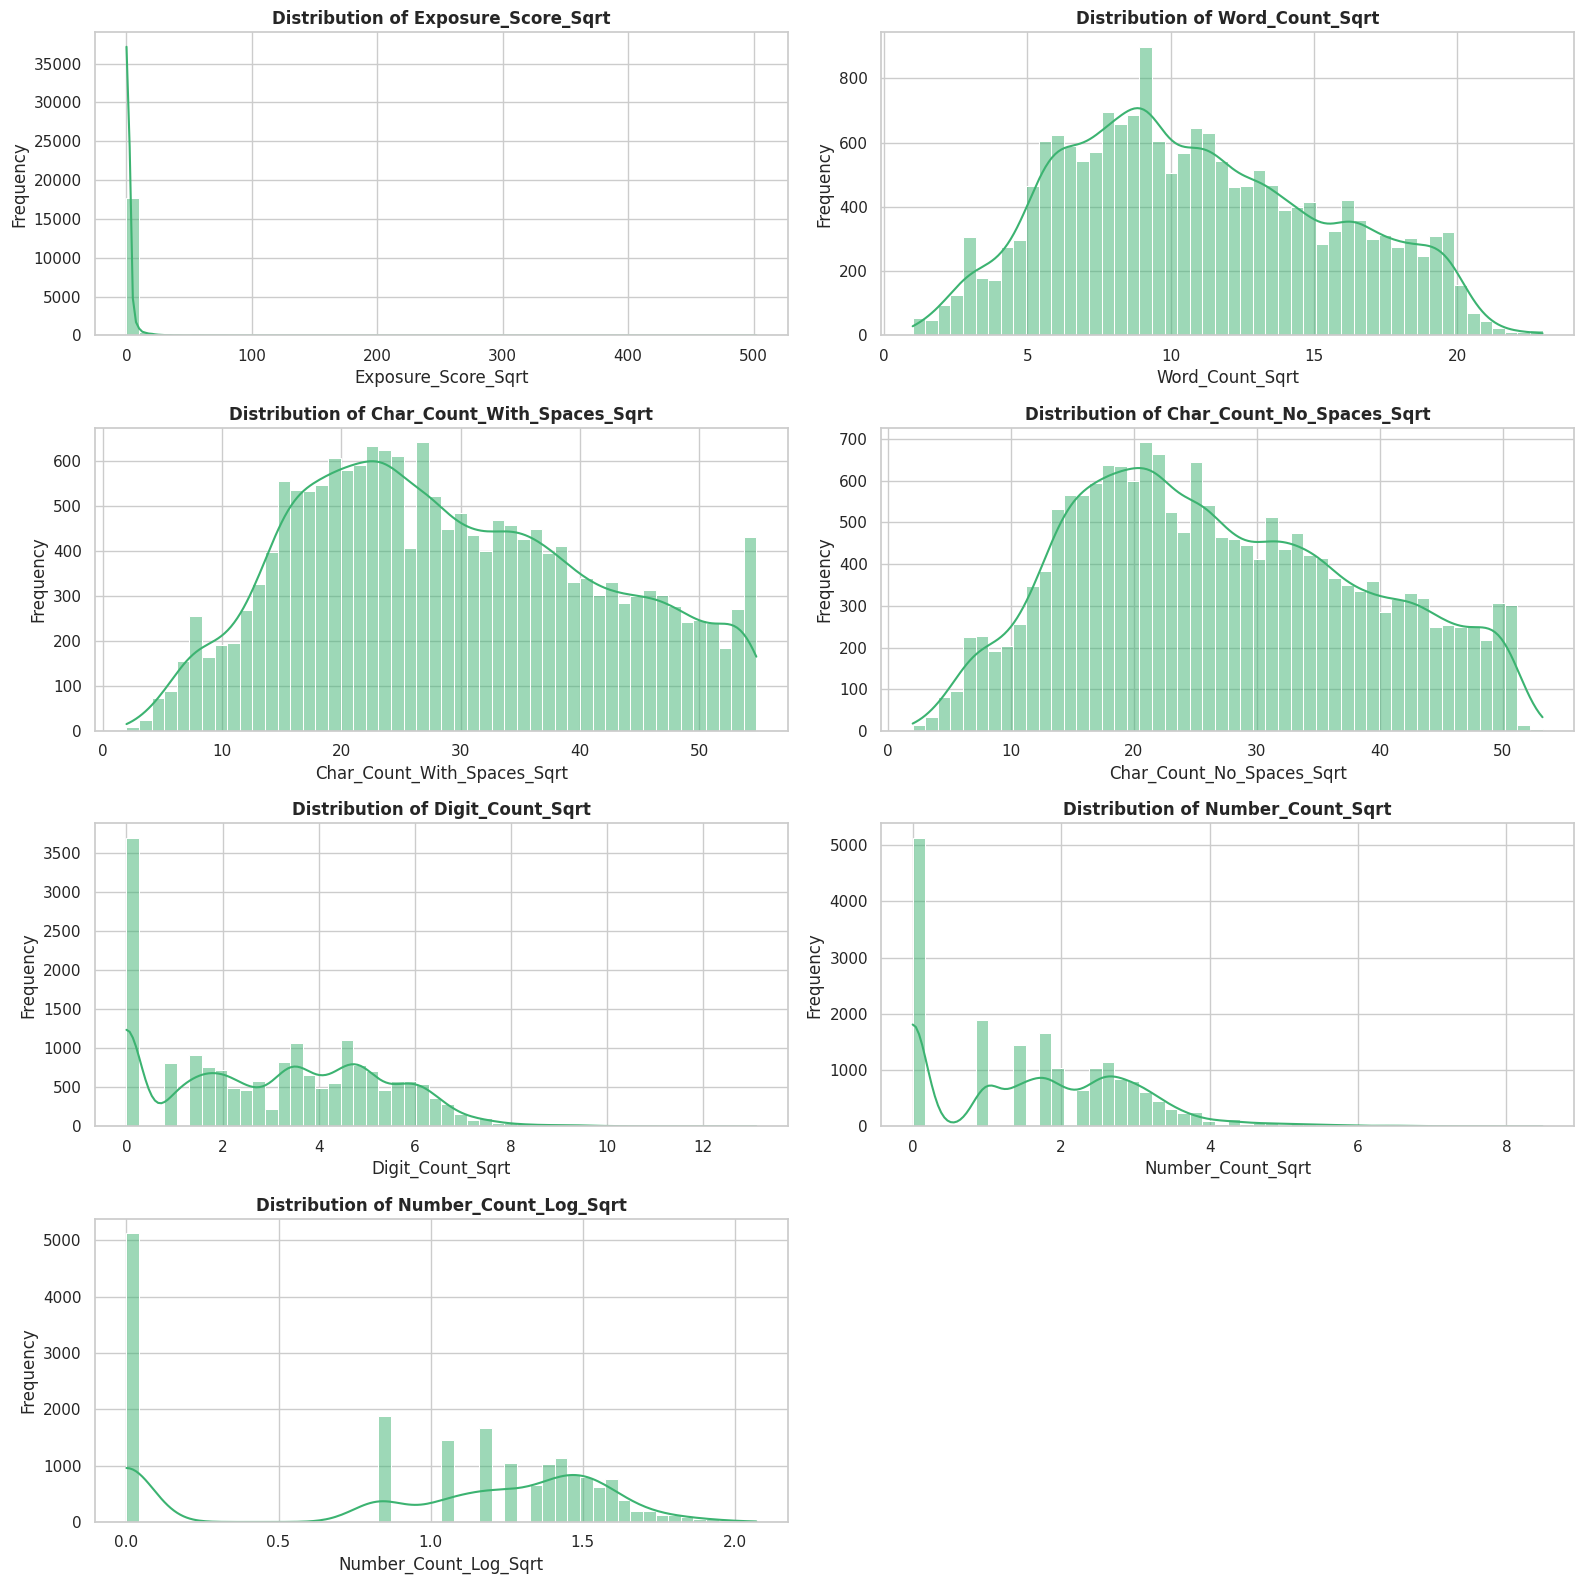

In [17]:
# Define the new transformed columns to visualize

sqrt_cols = [
    'Exposure_Score_Sqrt',
    'Word_Count_Sqrt',
    'Char_Count_With_Spaces_Sqrt',
    'Char_Count_No_Spaces_Sqrt',
    'Digit_Count_Sqrt',
    'Number_Count_Sqrt',
    'Number_Count_Log_Sqrt',
    'Digit_Count_Log_Sqrt',
]

# Set the visualization style
sns.set_theme(style="whitegrid")

# Create a figure with subplots (4 rows, 2 columns for 7 features)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 16))
axes = axes.flatten()


# Plot the distribution (histogram + KDE) for each transformed feature
for i, col in enumerate(sqrt_cols):
    sns.histplot(class_df[col], bins=50, kde=True, ax=axes[i], color='mediumseagreen')
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')


# Remove the last empty subplot (since we have exactly 7 features, not 8)
fig.delaxes(axes[7])

# Adjust layout
plt.tight_layout()

plt.show()

Power_03 Transformation

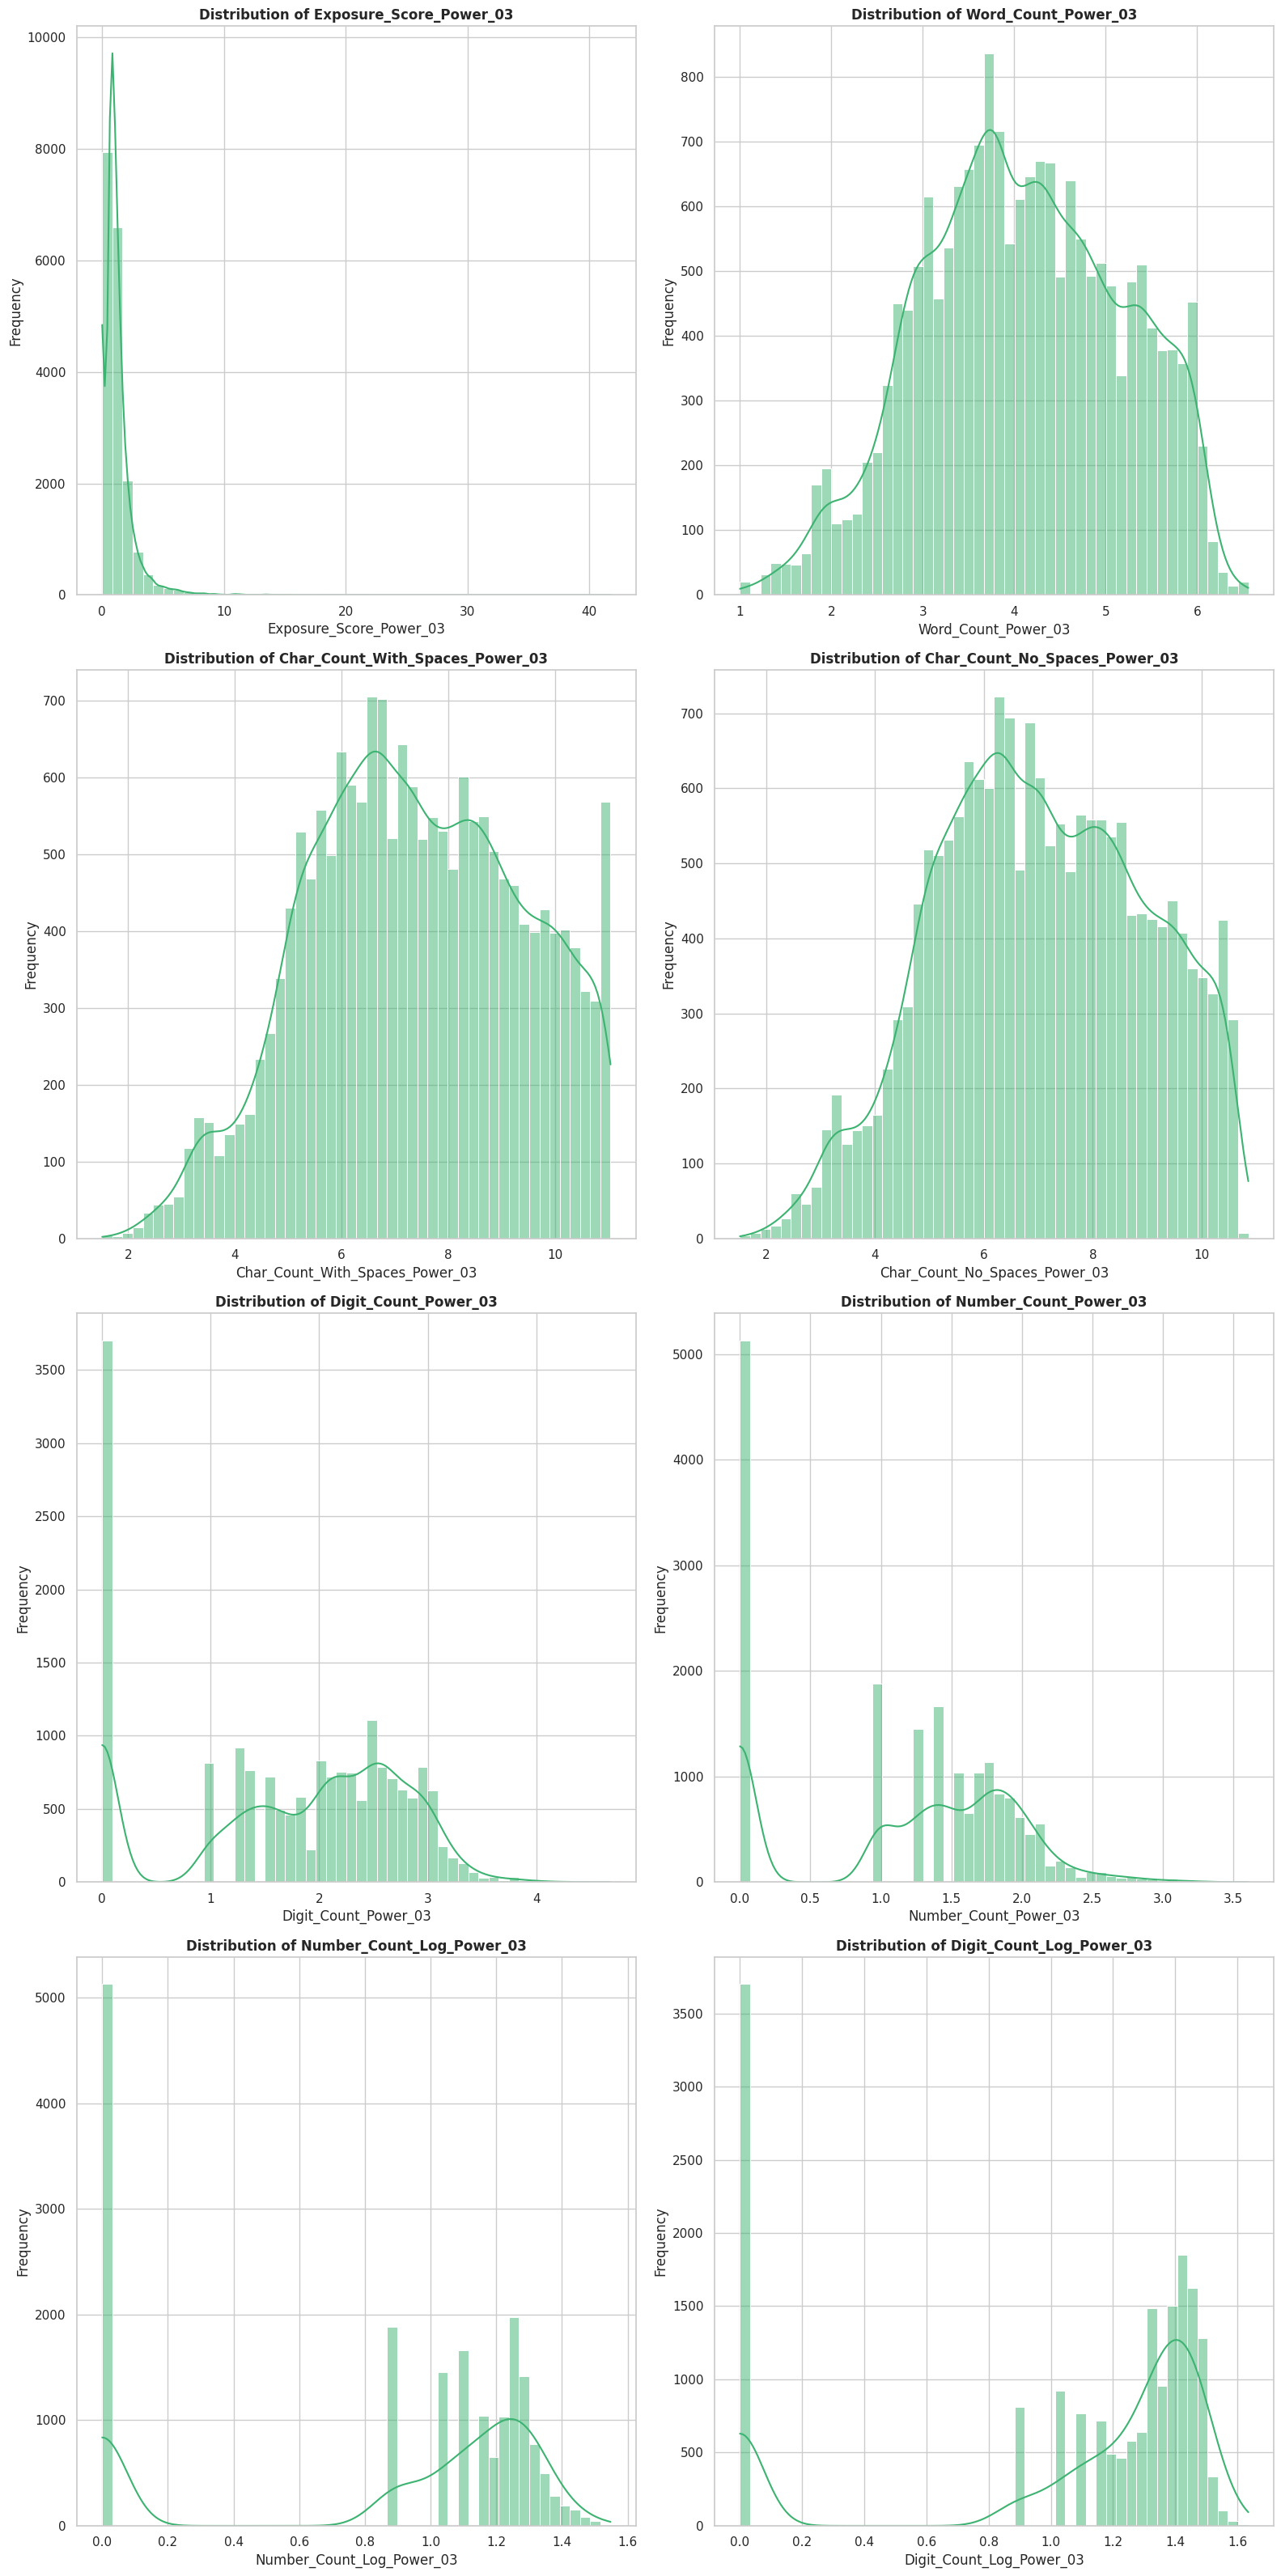

In [18]:
# Define the new transformed columns to visualize (16 features total)
sqrt_cols = [
    'Exposure_Score_Power_03',
    'Word_Count_Power_03',
    'Char_Count_With_Spaces_Power_03',
    'Char_Count_No_Spaces_Power_03',
    'Digit_Count_Power_03',
    'Number_Count_Power_03',
    'Number_Count_Log_Power_03',
    'Digit_Count_Log_Power_03'
]

# Set the visualization style
sns.set_theme(style="whitegrid")

# Create a figure with subplots (8 rows, 2 columns for 16 features)
# Increased the height (figsize) to 32 to accommodate all 8 rows comfortably
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 32))
axes = axes.flatten()

# Plot the distribution (histogram + KDE) for each transformed feature
for i, col in enumerate(sqrt_cols):
    # Check if column exists to avoid errors
    if col in class_df.columns:
        sns.histplot(class_df[col], bins=50, kde=True, ax=axes[i], color='mediumseagreen')
        axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

# Adjust layout to prevent overlapping text
plt.tight_layout()
plt.show()

As you can  see:

The transformetion of the distribution in the features didn't worked at all
so i moving to other methods.

In [19]:
# Features that need transformation
problematic_cols = [
    'Exposure_Score',
    'Word_Count',
    'Char_Count_With_Spaces',
    'Char_Count_No_Spaces',
    'Digit_Count',
    'Number_Count',
    'Number_Count_Log',
    'Digit_Count_Log',
]

# ==========================================
# 1. Bucketizing / Binning
# ==========================================

# Using pandas qcut to create equal-sized buckets (quantiles).
# 'duplicates=drop' handles cases where many identical values exist (like many zeros).
for col in problematic_cols:
    # Creates 5 bins, represented as categorical intervals
    # Convert to integer labels (0-4) instead of Interval objects for numerical processing
    class_df[f'{col}_Binned'] = pd.qcut(class_df[col], q=5, labels=False, duplicates='drop')


# ==========================================
# 2. Gaussian RBF (Radial Basis Function)
# ==========================================

# Example specifically for 'Digit_Count_Log' which has multiple peaks.
# We will use KMeans to find 3 centers (the "peaks") and calculate RBF distance to them.

X_feature = class_df[['Digit_Count_Log']].fillna(0)

# Find 3 cluster centers (landmarks) representing the peaks
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_feature)
centers = kmeans.cluster_centers_

# Apply the RBF kernel: exp(-gamma * ||x - center||^2)
# gamma controls the width of the bell curve (higher gamma = narrower bell)
rbf_features = rbf_kernel(X_feature, centers, gamma=1.0)

# Add the 3 new RBF features back to the DataFrame
for i in range(rbf_features.shape[1]):
    class_df[f'Digit_Count_Log_RBF_Center_{i}'] = rbf_features[:, i]

# You can wrap this RBF logic in a loop to apply it to all 'problematic_cols' if needed.

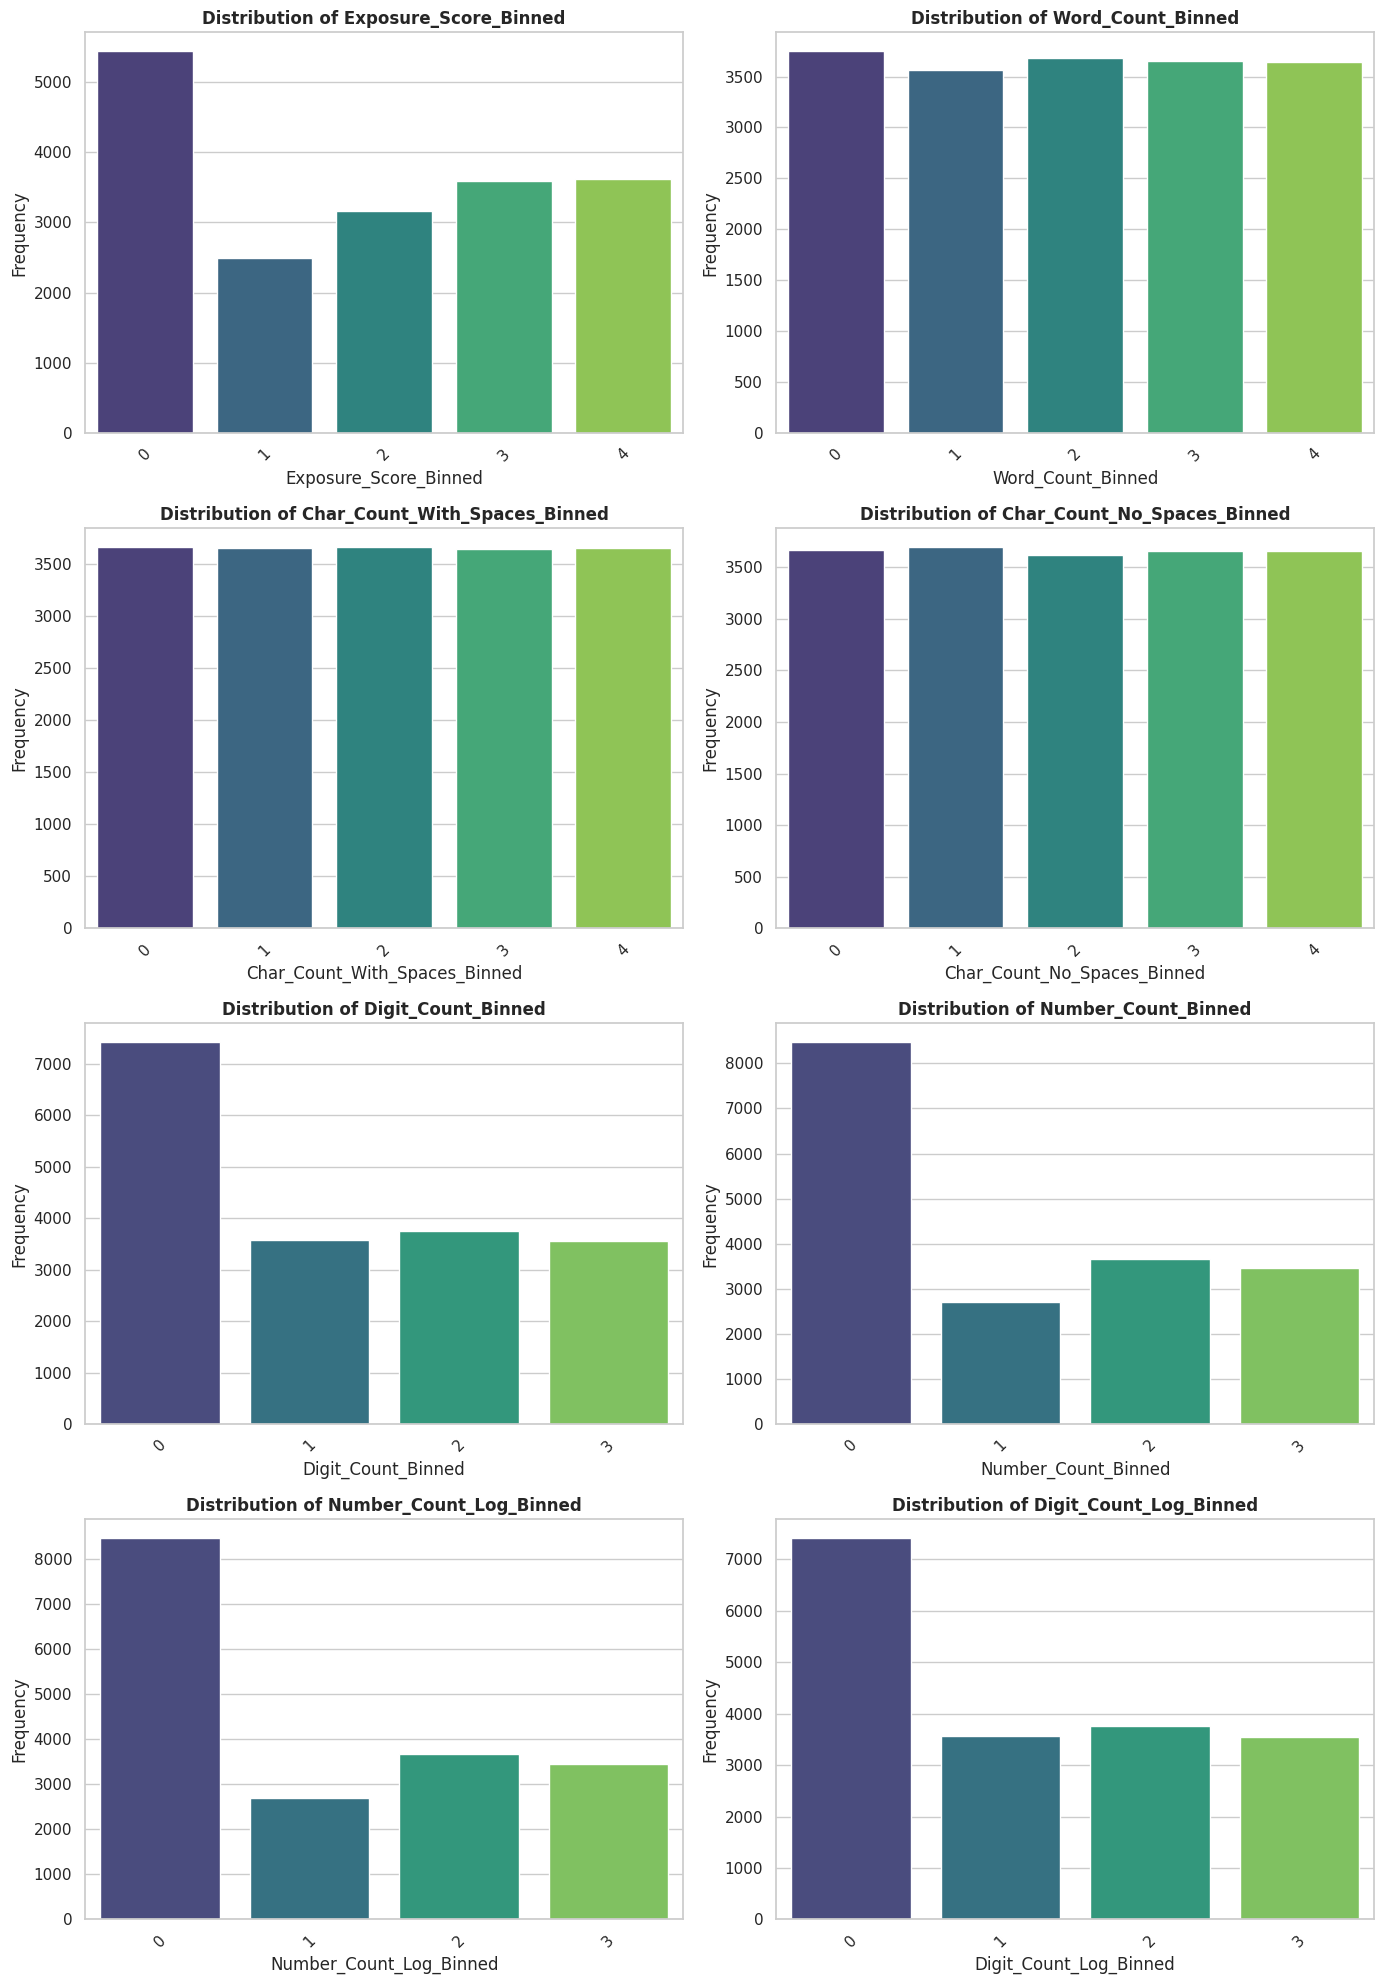

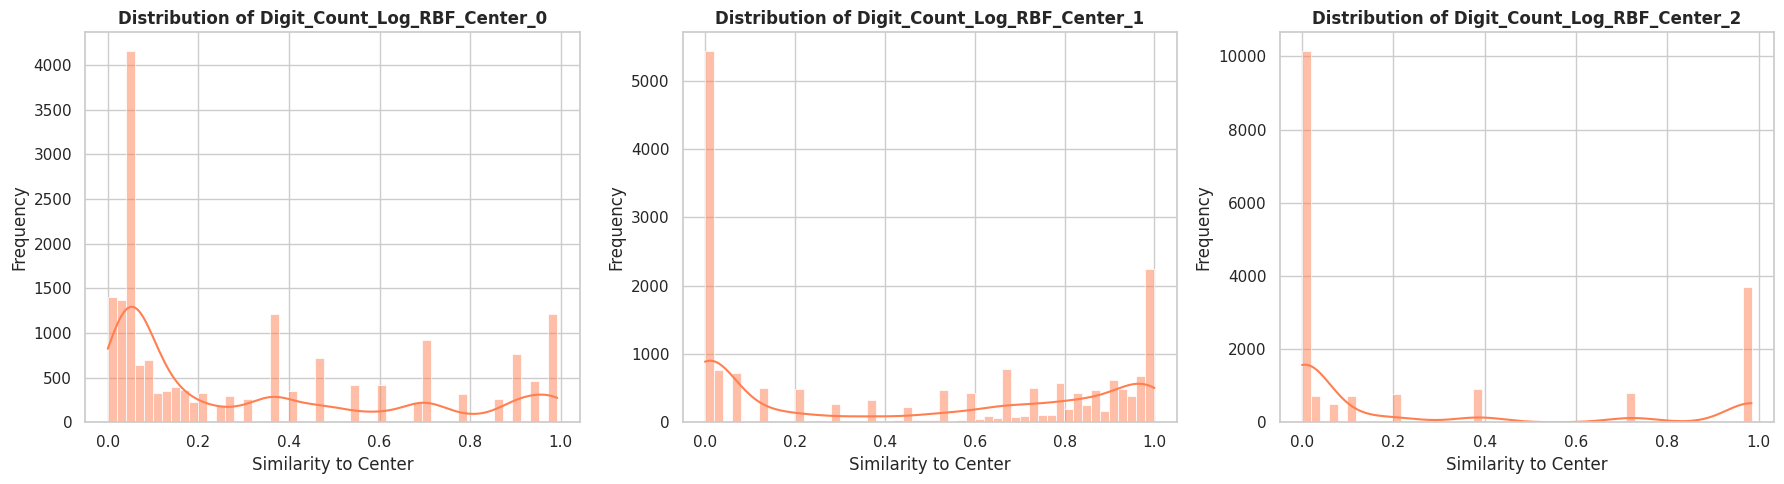

In [20]:
problematic_cols = [
    'Exposure_Score',
    'Word_Count',
    'Char_Count_With_Spaces',
    'Char_Count_No_Spaces',
    'Digit_Count',
    'Number_Count',
    'Number_Count_Log',
    'Digit_Count_Log',
]
sns.set_theme(style="whitegrid")

# ==========================================
# 1. Visualize Binning (Categorical)
# ==========================================
# Create a figure with enough subplots for all problematic_cols (8 features)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 20)) # Changed nrows to 4 and figsize
axes = axes.flatten()

for i, col in enumerate(problematic_cols):
    binned_col = f'{col}_Binned'

    # Check if the column exists in the DataFrame
    if binned_col in class_df.columns:
        sns.countplot(data=class_df, x=binned_col, ax=axes[i], palette='viridis')
        axes[i].set_title(f'Distribution of {binned_col}', fontsize=12, fontweight='bold')
        # Rotate x labels for better readability of the intervals
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_ylabel('Frequency')

# Adjust layout to prevent overlapping text
plt.tight_layout()
plt.show()

# ==========================================
# 2. Visualize Gaussian RBF (Continuous)
# ==========================================
# Assuming we created 3 RBF centers for 'Digit_Count_Log' as an example
rbf_cols = [f'Digit_Count_Log_RBF_Center_{i}' for i in range(3)]

# Check if at least the first RBF column exists
if rbf_cols[0] in class_df.columns:
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
    axes = axes.flatten()

    for i, col in enumerate(rbf_cols):
        sns.histplot(class_df[col], bins=50, kde=True, ax=axes[i], color='coral')
        axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Similarity to Center')
        axes[i].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

Gaussian RBF transformtion

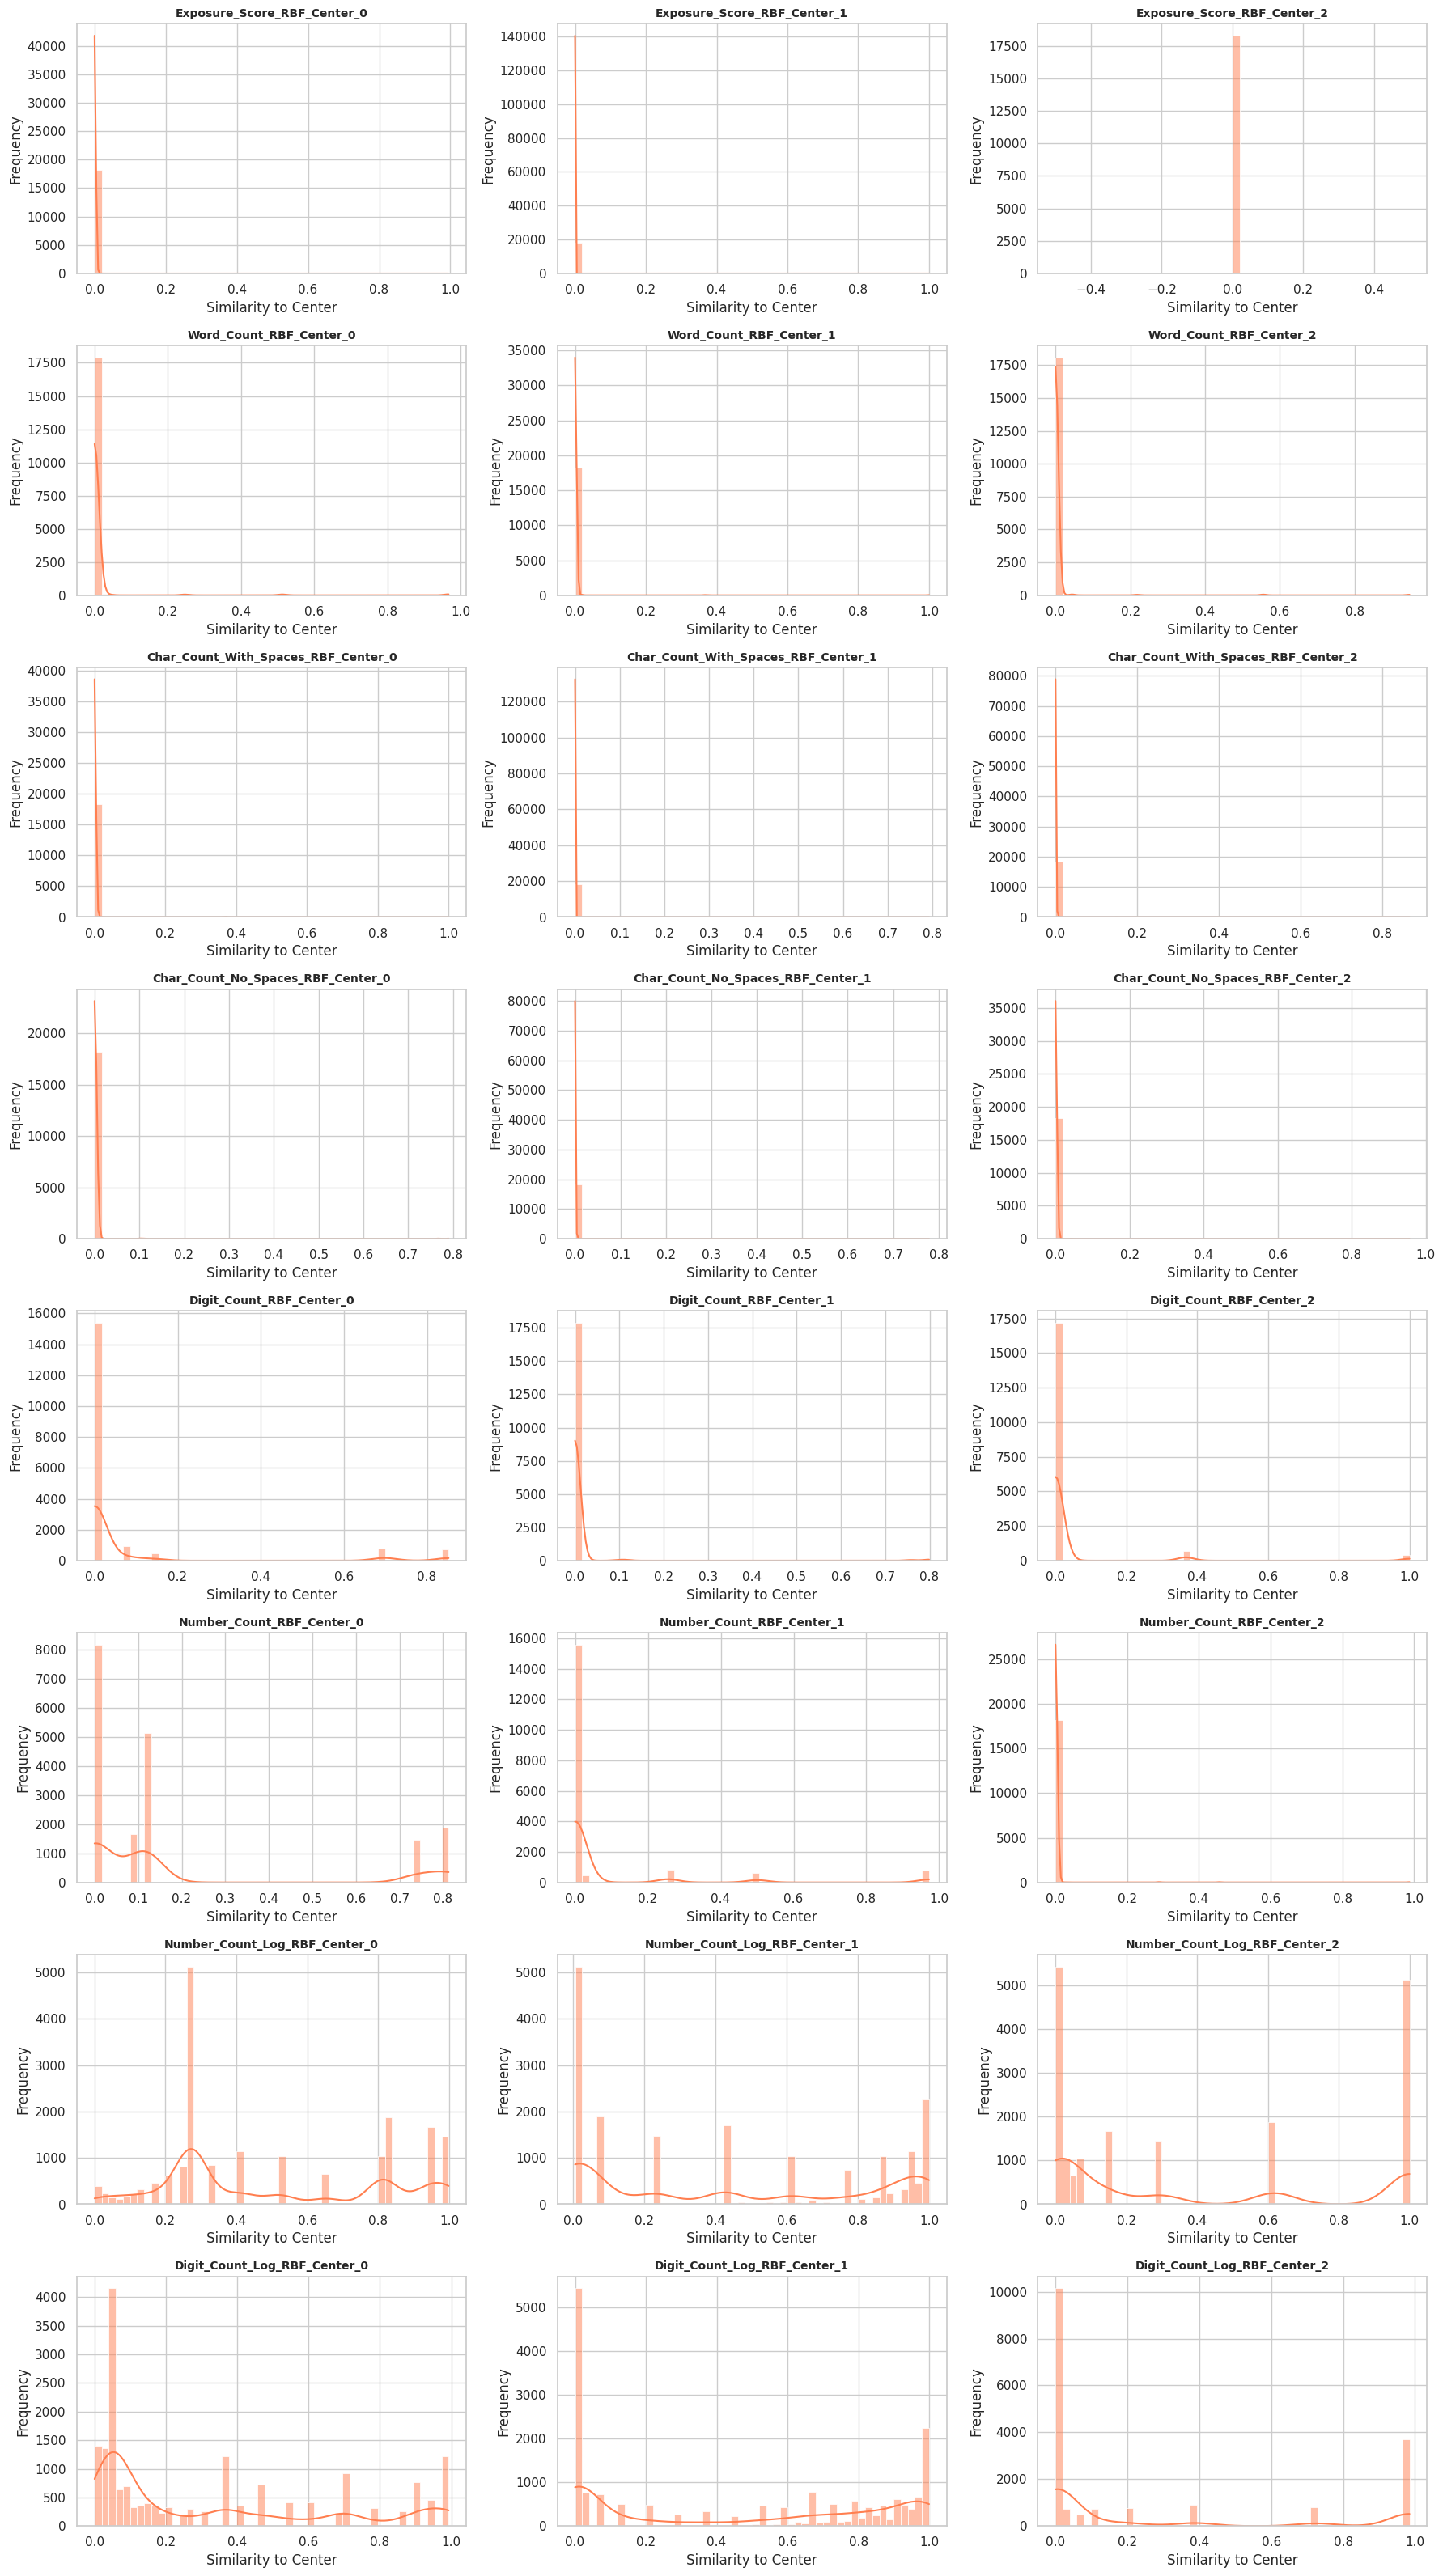

In [21]:
problematic_cols = [
    'Exposure_Score',
    'Word_Count',
    'Char_Count_With_Spaces',
    'Char_Count_No_Spaces',
    'Digit_Count',
    'Number_Count',
    'Number_Count_Log',
    'Digit_Count_Log',
]

sns.set_theme(style="whitegrid")
rbf_generated_cols = []

# ==========================================
# 1. Generate Gaussian RBF Features for ALL columns
# ==========================================
for col in problematic_cols:
    # Handle any potential missing values by filling with 0
    X_feature = class_df[[col]].fillna(0)

    # Find 3 cluster centers (landmarks) representing the peaks for the current feature
    kmeans = KMeans(n_clusters=3, random_state=42)
    kmeans.fit(X_feature)
    centers = kmeans.cluster_centers_

    # Apply the RBF kernel
    rbf_features = rbf_kernel(X_feature, centers, gamma=1.0)

    # Add the 3 new RBF features back to the DataFrame
    for i in range(3):
        new_col_name = f'{col}_RBF_Center_{i}'
        class_df[new_col_name] = rbf_features[:, i]
        rbf_generated_cols.append(new_col_name)

# ==========================================
# 2. Visualize all new Gaussian RBF Features
# ==========================================
# Create a figure with 8 rows (one for each original feature) and 3 columns (one for each center)
fig, axes = plt.subplots(nrows=len(problematic_cols), ncols=3, figsize=(18, 4 * len(problematic_cols)))

for i, new_col in enumerate(rbf_generated_cols):
    # Calculate row and column index for the grid
    row_idx = i // 3
    col_idx = i % 3

    sns.histplot(class_df[new_col], bins=50, kde=True, ax=axes[row_idx, col_idx], color='coral')
    axes[row_idx, col_idx].set_title(f'{new_col}', fontsize=10, fontweight='bold')
    axes[row_idx, col_idx].set_xlabel('Similarity to Center')
    axes[row_idx, col_idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Again, you can see the Gaussian RBF didn't transform the features values to normal distributions therefore I will use the Binning transfomation that transform the features values to uniform distrebutions.


In [22]:
class_df.columns

Index(['Original_DataFrame_Index', 'Original_Text', 'Exposure_Score',
       'Label_Has_PII', 'Word_Count', 'Char_Count_With_Spaces',
       'Char_Count_No_Spaces', 'Digit_Count', 'Number_Count',
       'Number_Count_Log', 'Digit_Count_Log', 'Char_Count_Log',
       'Word_Count_Log', 'Exposure_Score_Sqrt', 'Exposure_Score_Power_03',
       'Word_Count_Sqrt', 'Word_Count_Power_03', 'Char_Count_With_Spaces_Sqrt',
       'Char_Count_With_Spaces_Power_03', 'Char_Count_No_Spaces_Sqrt',
       'Char_Count_No_Spaces_Power_03', 'Digit_Count_Sqrt',
       'Digit_Count_Power_03', 'Number_Count_Sqrt', 'Number_Count_Power_03',
       'Number_Count_Log_Sqrt', 'Number_Count_Log_Power_03',
       'Digit_Count_Log_Sqrt', 'Digit_Count_Log_Power_03',
       'Exposure_Score_Binned', 'Word_Count_Binned',
       'Char_Count_With_Spaces_Binned', 'Char_Count_No_Spaces_Binned',
       'Digit_Count_Binned', 'Number_Count_Binned', 'Number_Count_Log_Binned',
       'Digit_Count_Log_Binned', 'Digit_Count_Log_RBF_

In [23]:
# Droping the columns witch the transformation didn't work

cols_to_drop = [
       'Exposure_Score_Power_03',
       'Word_Count_Power_03',
       'Char_Count_With_Spaces_Power_03',
       'Char_Count_No_Spaces_Power_03',
       'Digit_Count_Power_03',
       'Number_Count_Power_03',
       'Number_Count_Log_Power_03',
       'Digit_Count_Log_Power_03',
       'Digit_Count_Log_RBF_Center_0',
       'Digit_Count_Log_RBF_Center_1', 'Digit_Count_Log_RBF_Center_2',
       'Exposure_Score_RBF_Center_0', 'Exposure_Score_RBF_Center_1',
       'Exposure_Score_RBF_Center_2', 'Word_Count_RBF_Center_0',
       'Word_Count_RBF_Center_1', 'Word_Count_RBF_Center_2',
       'Char_Count_With_Spaces_RBF_Center_0',
       'Char_Count_With_Spaces_RBF_Center_1',
       'Char_Count_With_Spaces_RBF_Center_2',
       'Char_Count_No_Spaces_RBF_Center_0',
       'Char_Count_No_Spaces_RBF_Center_1',
       'Char_Count_No_Spaces_RBF_Center_2', 'Digit_Count_RBF_Center_0',
       'Digit_Count_RBF_Center_1', 'Digit_Count_RBF_Center_2',
       'Number_Count_RBF_Center_0', 'Number_Count_RBF_Center_1',
       'Number_Count_RBF_Center_2', 'Number_Count_Log_RBF_Center_0',
       'Number_Count_Log_RBF_Center_1', 'Number_Count_Log_RBF_Center_2'
]

class_df = class_df.drop(columns=cols_to_drop)

In [24]:
X_train.columns

Index(['Original_DataFrame_Index', 'Original_Text', 'Exposure_Score',
       'Word_Count', 'Char_Count_With_Spaces', 'Char_Count_No_Spaces',
       'Digit_Count', 'Number_Count', 'Number_Count_Log', 'Digit_Count_Log',
       'Char_Count_Log', 'Word_Count_Log'],
      dtype='object')

In [25]:
X_test.columns

Index(['Original_DataFrame_Index', 'Original_Text', 'Exposure_Score',
       'Word_Count', 'Char_Count_With_Spaces', 'Char_Count_No_Spaces',
       'Digit_Count', 'Number_Count', 'Number_Count_Log', 'Digit_Count_Log',
       'Char_Count_Log', 'Word_Count_Log'],
      dtype='object')

In [26]:
# Adding the columns that transform successfuly to X_train & X_test
# List of the successfully transformed columns you want to add to X_train and X_test
successful_cols = [
    'Word_Count_Sqrt',
    'Char_Count_With_Spaces_Sqrt',
    'Char_Count_No_Spaces_Sqrt',
    'Exposure_Score_Binned',
    'Word_Count_Binned',
    'Char_Count_With_Spaces_Binned',
    'Char_Count_No_Spaces_Binned',
    'Digit_Count_Binned',
    'Number_Count_Binned',
    'Number_Count_Log_Binned',
    'Digit_Count_Log_Binned',
]

# Add each column safely using Original_DataFrame_Index as the matching key
for col in successful_cols:
    # Create a mapping dictionary from class_df: {Original_DataFrame_Index: Transformed_Value}
    mapping_dict = dict(zip(class_df['Original_DataFrame_Index'], class_df[col]))

    # Map the values to X_train and X_test based on their Original_DataFrame_Index
    X_train[col] = X_train['Original_DataFrame_Index'].map(mapping_dict)
    X_test[col] = X_test['Original_DataFrame_Index'].map(mapping_dict)

In [27]:
X_train.columns

Index(['Original_DataFrame_Index', 'Original_Text', 'Exposure_Score',
       'Word_Count', 'Char_Count_With_Spaces', 'Char_Count_No_Spaces',
       'Digit_Count', 'Number_Count', 'Number_Count_Log', 'Digit_Count_Log',
       'Char_Count_Log', 'Word_Count_Log', 'Word_Count_Sqrt',
       'Char_Count_With_Spaces_Sqrt', 'Char_Count_No_Spaces_Sqrt',
       'Exposure_Score_Binned', 'Word_Count_Binned',
       'Char_Count_With_Spaces_Binned', 'Char_Count_No_Spaces_Binned',
       'Digit_Count_Binned', 'Number_Count_Binned', 'Number_Count_Log_Binned',
       'Digit_Count_Log_Binned'],
      dtype='object')

In [28]:
X_test.columns

Index(['Original_DataFrame_Index', 'Original_Text', 'Exposure_Score',
       'Word_Count', 'Char_Count_With_Spaces', 'Char_Count_No_Spaces',
       'Digit_Count', 'Number_Count', 'Number_Count_Log', 'Digit_Count_Log',
       'Char_Count_Log', 'Word_Count_Log', 'Word_Count_Sqrt',
       'Char_Count_With_Spaces_Sqrt', 'Char_Count_No_Spaces_Sqrt',
       'Exposure_Score_Binned', 'Word_Count_Binned',
       'Char_Count_With_Spaces_Binned', 'Char_Count_No_Spaces_Binned',
       'Digit_Count_Binned', 'Number_Count_Binned', 'Number_Count_Log_Binned',
       'Digit_Count_Log_Binned'],
      dtype='object')

In [29]:
# List of all the numerical columns you want to scale
cols_to_scale = [
  'Number_Count_Log',
  'Digit_Count_Log',
  'Char_Count_Log',
  'Word_Count_Log',
  'Word_Count_Sqrt',
  'Char_Count_With_Spaces_Sqrt',
  'Char_Count_No_Spaces_Sqrt',
  'Exposure_Score_Binned',
  'Word_Count_Binned',
  'Char_Count_With_Spaces_Binned',
  'Char_Count_No_Spaces_Binned',
  'Digit_Count_Binned',
  'Number_Count_Binned',
  'Number_Count_Log_Binned',
  'Digit_Count_Log_Binned'
]

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler ONLY on X_train, and transform both X_train and X_test
# The scaled values replace the original values in the same columns
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

## **Models**

In [30]:
models_params = {
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [None, 10, 20, 30, 40],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'class_weight': [None, 'balanced']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'class_weight': ['balanced', 'balanced_subsample']
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, eval_metric='logloss'),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 7, 10],
            'learning_rate': [0.01, 0.1, 0.2],
            'subsample': [0.8, 1.0],
            'scale_pos_weight': [1, 5, 10] # Helps handle imbalanced data
        }
    }
}

results = []

# List of the successfully transformed columns you want to add to X_train and X_test
# This needs to be defined globally as it is used within the loop.
successful_cols = [
    'Word_Count_Sqrt',
    'Char_Count_With_Spaces_Sqrt',
    'Char_Count_No_Spaces_Sqrt',
    'Exposure_Score_Binned',
    'Word_Count_Binned',
    'Char_Count_With_Spaces_Binned',
    'Char_Count_No_Spaces_Binned',
    'Digit_Count_Binned',
    'Number_Count_Binned',
    'Number_Count_Log_Binned',
    'Digit_Count_Log_Binned'
]

# --- Start of fix (old code, no longer used for model training directly below) ---
# This section prepares X_train_final_model and X_test_final_model using the first split,
# but the subsequent loop re-creates these for each split.
# Select the numerical/processed columns from X_train and X_test DataFrames
# These columns are already scaled from the previous step (uEc4LZWBHp2k)
X_train_numerical_processed = X_train[cols_to_scale]
X_test_numerical_processed = X_test[cols_to_scale]

# Convert these numerical features to a sparse matrix format to concatenate with text features
# using csr_matrix for efficient sparse matrix operations
X_train_numerical_sparse = csr_matrix(X_train_numerical_processed)
X_test_numerical_sparse = csr_matrix(X_test_numerical_processed)

# Combine all features: numerical, count vectors, and TF-IDF
# X_train_counts and X_train_tfidf were created in cell 4J9YbNq6YWja
X_train_final_model = hstack([X_train_numerical_sparse, X_train_counts, X_train_tfidf])
X_test_final_model = hstack([X_test_numerical_sparse, X_test_counts, X_test_tfidf])
# --- End of fix ---

########################## XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX ##########################

# The commented-out block below is an alternative way of running RandomizedSearchCV
# on a single train-test split (the first one).
# This code is currently not active.

# # Loop through models, perform RandomizedSearchCV, and evaluate
# for model_name, mp in models_params.items():
#     # Initialize RandomizedSearchCV
#     # n_iter controls how many random combinations to try
#     # cv=3 means 3-fold cross validation
#     clf = RandomizedSearchCV(
#         mp['model'],
#         mp['params'],
#         n_iter=10,
#         cv=3,
#         scoring='f1', # Optimizing for F1-score due to imbalanced data
#         random_state=42,
#         n_jobs=-1
#     )

#     # Fit the model using the combined numerical and text features
#     clf.fit(X_train_final_model, y_train)

#     # Predict on the test set using the best estimator found
#     best_model = clf.best_estimator_
#     y_pred = best_model.predict(X_test_final_model)

#     # Calculate classification metrics
#     acc = accuracy_score(y_test, y_pred)
#     prec = precision_score(y_test, y_pred, zero_division=0)
#     rec = recall_score(y_test, y_pred, zero_division=0)
#     f1 = f1_score(y_test, y_pred, zero_division=0)

#     # Store results
#     results.append({
#         'Model': model_name,
#         'Accuracy': acc,
#         'Precision': prec,
#         'Recall': rec,
#         'F1-Score': f1,
#         'Best Params': clf.best_params_
#     })

# # Convert results to DataFrame for easy comparison
# results_df = pd.DataFrame(results)


########################## XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX ##########################


import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
from sklearn.metrics import f1_score
from sklearn.model_selection import RandomizedSearchCV

# List to store the final results for all models
all_models_results = []

# Main loop: iterate over each model defined in models_params
for model_name, mp in models_params.items():
    print(f"\n================ Training and evaluating: {model_name} ================")

    model_f1_scores = []

    # Inner loop: cross-validate across all 5 splits for the current model
    for i, (X_train_split, X_test_split, y_train_split, y_test_split) in enumerate(splits):
        # Map the successful columns to X_train_split and X_test_split for the current split
        # This ensures the engineered features are available in each split's DataFrame
        for col in successful_cols:
            mapping_dict = dict(zip(class_df['Original_DataFrame_Index'], class_df[col]))
            X_train_split[col] = X_train_split['Original_DataFrame_Index'].map(mapping_dict)
            X_test_split[col] = X_test_split['Original_DataFrame_Index'].map(mapping_dict)

        # 1. Feature Engineering at Corpus Level (Fit on Train ONLY, transform both)
        count_vec = CountVectorizer()
        X_train_counts = count_vec.fit_transform(X_train_split['Original_Text'])
        X_test_counts = count_vec.transform(X_test_split['Original_Text'])

        tfidf_vec = TfidfVectorizer()
        X_train_tfidf = tfidf_vec.fit_transform(X_train_split['Original_Text'])
        X_test_tfidf = tfidf_vec.transform(X_test_split['Original_Text'])

        scaler = StandardScaler()
        # The error occurred here because cols_to_scale were not in X_train_split
        X_train_scaled = scaler.fit_transform(X_train_split[cols_to_scale])
        X_test_scaled = scaler.transform(X_test_split[cols_to_scale])

        X_train_sparse = csr_matrix(X_train_scaled)
        X_test_sparse = csr_matrix(X_test_scaled)

        # 2. Combine all features
        X_train_final = hstack([X_train_sparse, X_train_counts, X_train_tfidf])
        X_test_final = hstack([X_test_sparse, X_test_counts, X_test_tfidf])

        # 3. Hyperparameter search and training on the current split
        clf = RandomizedSearchCV(
            mp['model'],
            mp['params'],
            n_iter=5, # Reduced iterations to save runtime during CV
            cv=3,
            scoring='f1_macro',
            random_state=42,
            n_jobs=-1
        )

        clf.fit(X_train_final, y_train_split)

        # 4. Predict using the best estimator and calculate Macro F1 score
        y_pred = clf.best_estimator_.predict(X_test_final)
        score = f1_score(y_test_split, y_pred, average='macro')

        model_f1_scores.append(score)
        print(f"  - Split {i+1} Macro F1: {score:.3f}")

    # Calculate mean and standard deviation across all splits
    mean_f1 = np.mean(model_f1_scores)
    std_f1 = np.std(model_f1_scores)
    print(f">> {model_name} Final Score: {mean_f1:.3f} ± {std_f1:.3f}")

    # Store results
    all_models_results.append({
        'Model': model_name,
        'Mean Macro F1': mean_f1,
        'Std Macro F1': std_f1
    })

# 5. Display the final comparison table
print("\n================ Models Results Summary ================")
results_df = pd.DataFrame(all_models_results)
results_df




# Display the comparison table
# This line will cause an error because 'Accuracy', 'Precision', 'Recall', 'F1-Score' are not in results_df
# as it now contains 'Mean Macro F1' and 'Std Macro F1'
# results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']]



================ Training and evaluating: Decision Tree ================
  - Split 1 Macro F1: 0.775
  - Split 2 Macro F1: 0.776
  - Split 3 Macro F1: 0.777
  - Split 4 Macro F1: 0.770
  - Split 5 Macro F1: 0.767
>> Decision Tree Final Score: 0.773 ± 0.004

================ Training and evaluating: Random Forest ================
  - Split 1 Macro F1: 0.793
  - Split 2 Macro F1: 0.808
  - Split 3 Macro F1: 0.784
  - Split 4 Macro F1: 0.794
  - Split 5 Macro F1: 0.776
>> Random Forest Final Score: 0.791 ± 0.011

================ Training and evaluating: XGBoost ================
  - Split 1 Macro F1: 0.803
  - Split 2 Macro F1: 0.827
  - Split 3 Macro F1: 0.801
  - Split 4 Macro F1: 0.810
  - Split 5 Macro F1: 0.803
>> XGBoost Final Score: 0.809 ± 0.010

================ Models Results Summary ================


,Model,Mean Macro F1,Std Macro F1
0,Decision Tree,0.773220,0.003983
1,Random Forest,0.790996,0.010611
2,XGBoost,0.808792,0.009708


In [31]:
# Define models and their hyperparameter search spaces
models_params = {
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [None, 10, 20, 30, 40],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'class_weight': [None, 'balanced']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'class_weight': ['balanced', 'balanced_subsample']
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, eval_metric='logloss'),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 7, 10],
            'learning_rate': [0.01, 0.1, 0.2],
            'subsample': [0.8, 1.0],
            'scale_pos_weight': [1, 5, 10]
        }
    }
}

# --- Start of fix ---
# Select the numerical/processed columns from X_train and X_test DataFrames
# These columns are already scaled from the previous step (uEc4LZWBHp2k)
X_train_numerical_processed = X_train[cols_to_scale]
X_test_numerical_processed = X_test[cols_to_scale]

# Convert these numerical features to a sparse matrix format to concatenate with text features
# using csr_matrix for efficient sparse matrix operations
X_train_numerical_sparse = csr_matrix(X_train_numerical_processed)
X_test_numerical_sparse = csr_matrix(X_test_numerical_processed)

# Combine all features: numerical, count vectors, and TF-IDF
# X_train_counts and X_train_tfidf were created in cell 4J9YbNq6YWja
X_train_final_model = hstack([X_train_numerical_sparse, X_train_counts, X_train_tfidf])
X_test_final_model = hstack([X_test_numerical_sparse, X_test_counts, X_test_tfidf])
# --- End of fix ---

# Loop through models, perform RandomizedSearchCV, and print per-class evaluation
for model_name, mp in models_params.items():
    print(f"================ {model_name} ================")

    clf = RandomizedSearchCV(
        mp['model'],
        mp['params'],
        n_iter=10,
        cv=3,
        scoring='f1_macro',
        random_state=42,
        n_jobs=-1
    )

    # Fit the model using the combined numerical and text features
    clf.fit(X_train_final_model, y_train)

    # Predict on the test set using the best estimator found
    best_model = clf.best_estimator_
    y_pred = best_model.predict(X_test_final_model)

    # Print the per-class metrics report
    print(classification_report(y_test, y_pred))
    print("\n")

================ Decision Tree ================
              precision    recall  f1-score   support

           0       0.43      0.94      0.59       247
           1       0.99      0.91      0.95      3411

    accuracy                           0.91      3658
   macro avg       0.71      0.92      0.77      3658
weighted avg       0.96      0.91      0.93      3658



================ Random Forest ================
              precision    recall  f1-score   support

           0       0.67      0.56      0.61       247
           1       0.97      0.98      0.97      3411

    accuracy                           0.95      3658
   macro avg       0.82      0.77      0.79      3658
weighted avg       0.95      0.95      0.95      3658



================ XGBoost ================
              precision    recall  f1-score   support

           0       0.70      0.57      0.63       247
           1       0.97      0.98      0.98      3411

    accuracy                           0

In [34]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
from sklearn.metrics import f1_score
from xgboost import XGBClassifier

all_macro_f1_scores = []

# כאן אתה מכניס את המודל והפרמטרים הטובים ביותר שמצאת
best_model = XGBClassifier(
    scale_pos_weight=5,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# List of the successfully transformed columns you want to add to X_train and X_test
successful_cols = [
    'Word_Count_Sqrt',
    'Char_Count_With_Spaces_Sqrt',
    'Char_Count_No_Spaces_Sqrt',
    'Exposure_Score_Binned',
    'Word_Count_Binned',
    'Char_Count_With_Spaces_Binned',
    'Char_Count_No_Spaces_Binned',
    'Digit_Count_Binned',
    'Number_Count_Binned',
    'Number_Count_Log_Binned',
    'Digit_Count_Log_Binned'
]

# Splits
for i, (X_train_split, X_test_split, y_train_split, y_test_split) in enumerate(splits):

    # Map the successful columns to X_train_split and X_test_split for the current split
    for col in successful_cols:
        mapping_dict = dict(zip(class_df['Original_DataFrame_Index'], class_df[col]))
        X_train_split[col] = X_train_split['Original_DataFrame_Index'].map(mapping_dict)
        X_test_split[col] = X_test_split['Original_DataFrame_Index'].map(mapping_dict)

    # 1. Text transformation
    count_vec = CountVectorizer()
    X_train_counts = count_vec.fit_transform(X_train_split['Original_Text'])
    X_test_counts = count_vec.transform(X_test_split['Original_Text'])

    tfidf_vec = TfidfVectorizer()
    X_train_tfidf = tfidf_vec.fit_transform(X_train_split['Original_Text'])
    X_test_tfidf = tfidf_vec.transform(X_test_split['Original_Text'])

    # 2. Transformations for numeric variables
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_split[cols_to_scale])
    X_test_scaled = scaler.transform(X_test_split[cols_to_scale])

    X_train_sparse = csr_matrix(X_train_scaled)
    X_test_sparse = csr_matrix(X_test_scaled)

    # 3. Unifying all features
    X_train_final = hstack([X_train_sparse, X_train_counts, X_train_tfidf])
    X_test_final = hstack([X_test_sparse, X_test_counts, X_test_tfidf])

#     # 4. Training and prediction
#     best_model.fit(X_train_final, y_train_split)
#     y_pred = best_model.predict(X_test_final)

#     # 5. calculate Macro F1
#     score = f1_score(y_test_split, y_pred, average='macro')
#     all_macro_f1_scores.append(score)
#     print(f"Split {i+1} Macro F1: {score:.3f}")

# print("\n================ Final Results ================")
# print(f"Mean Macro F1: {np.mean(all_macro_f1_scores):.3f} \u00b1 {np.std(all_macro_f1_scores):.3f}")

# 4. Training and prediction with custom threshold
best_model.fit(X_train_final, y_train_split)

# probabilities for class 1
y_proba = best_model.predict_proba(X_test_final)[:, 1]

# choose threshold
best_threshold = 0.83

# convert probabilities to class labels
y_pred = (y_proba >= best_threshold).astype(int)

# 5. Calculate Macro F1
score = f1_score(y_test_split, y_pred, average='macro')
all_macro_f1_scores.append(score)

print(f"Split {i+1} Macro F1: {score:.3f}")

Split 5 Macro F1: 0.827


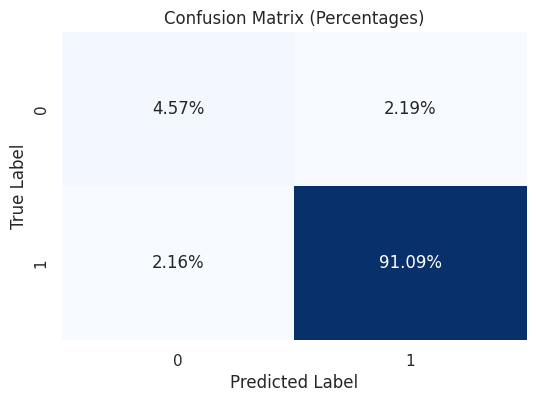

In [35]:
from sklearn.metrics import confusion_matrix

# Calculate the standard confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Convert to percentages (divide by the total number of samples)
cm_percent = cm.astype('float') / cm.sum()

# Set up the figure size
plt.figure(figsize=(6, 4))

# Create a heatmap using seaborn
# fmt='.2%' formats the values as percentages (e.g., 95.50%)
# annot=True displays the values inside the squares
sns.heatmap(cm_percent, annot=True, fmt='.2%', cmap='Blues', cbar=False)

# Add title and axis labels
plt.title('Confusion Matrix (Percentages)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Display the plot
plt.show()